In [1]:
# Sentiment Analysis on IMDB Movie Reviews
#**Goal:** Classify movie reviews as Positive or Negative using NLP  
#**Dataset:** IMDB (50,000 reviews)  
#**Model:** TF-IDF + Logistic Regression  
#**Accuracy:** ~87%  
#**Author:** Sanjivani Chewale  
#**Date:** April 2026 
import sys
!{sys.executable} -m pip install scikit-learn spacy datasets matplotlib seaborn wordcloud
!{sys.executable} -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Hp\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - ------------------------------------- 0.5/12.8 MB 932.9 kB/s eta 0:00:14
     -- ------------------------------------ 0.8/12.8 MB 987.4 kB/s eta 0:00:13
     -- ------------------------------------ 0.8/12.8 MB 987.4 kB/s eta 0:00:13
     --- ----------------------------------- 1.0/12.8 MB 853.0 kB/s eta 0:00:14
     --- ----------------------------------- 1.0/12.8 MB 853.0 kB/s eta 0:00:14
     --- ----------------------------------- 1.3/12.8 MB 894.7 kB/s eta 0:00:13
     --- ----------------------------------- 1.3/12.8 MB 894.7 kB/s eta 0:00:13
     ---- ---------------------------------- 1.6/12.8 MB 822.3 kB/s eta 0:00:14
     ---- ---------------------------------- 1.6/12.8 MB 822.3 kB/s eta 0:00:14
     ----- --------------------------------- 1.8/12.8 MB 724.2 k


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Hp\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from datasets import load_dataset
import spacy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
import warnings
warnings.filterwarnings('ignore')

nlp = spacy.load("en_core_web_sm")
print("✅ All libraries loaded!")

C:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All libraries loaded!


In [3]:
print("Loading IMDB dataset... (may take 1-2 mins first time)")
dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

train_df["sentiment"] = train_df["label"].map({0: "Negative", 1: "Positive"})
test_df["sentiment"] = test_df["label"].map({0: "Negative", 1: "Positive"})

print(f"✅ Training samples: {len(train_df)}")
print(f"✅ Test samples:     {len(test_df)}")
train_df.head()

Loading IMDB dataset... (may take 1-2 mins first time)


✅ Training samples: 25000
✅ Test samples:     25000


,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,Negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,Negative
2,If only to avoid making this type of film in t...,0,Negative
3,This film was probably inspired by Godard's Ma...,0,Negative
4,"Oh, brother...after hearing about this ridicul...",0,Negative


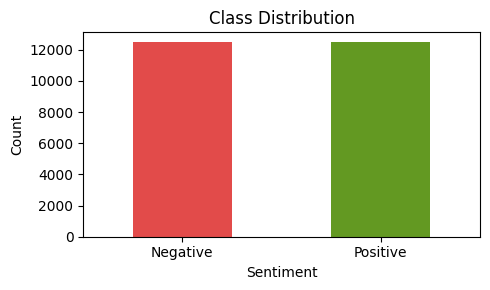

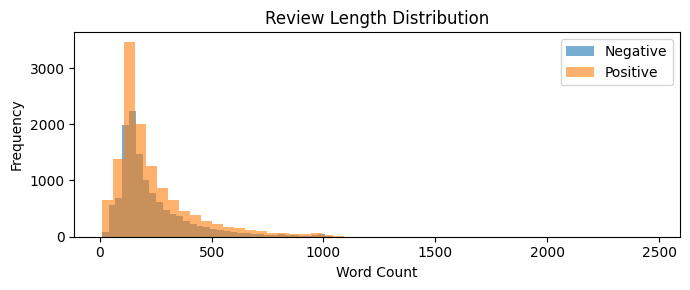

Average review length: 234 words


In [4]:
plt.figure(figsize=(5, 3))
train_df["sentiment"].value_counts().plot(kind="bar", color=["#E24B4A", "#639922"], edgecolor="none")
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

train_df["length"] = train_df["text"].apply(lambda x: len(x.split()))
plt.figure(figsize=(7, 3))
train_df.groupby("sentiment")["length"].plot(kind="hist", bins=50, alpha=0.6, legend=True)
plt.title("Review Length Distribution")
plt.xlabel("Word Count")
plt.tight_layout()
plt.show()

print(f"Average review length: {train_df['length'].mean():.0f} words")

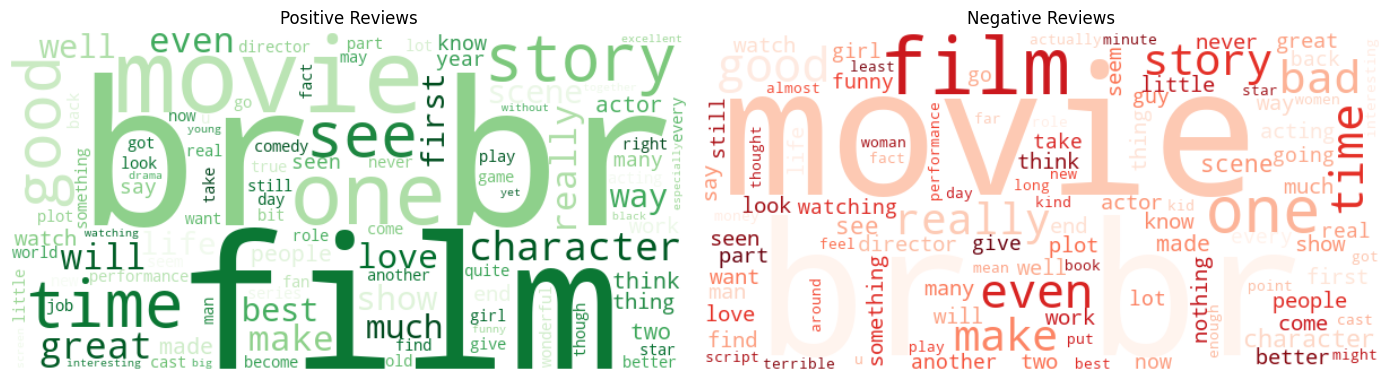

In [5]:
pos_text = " ".join(train_df[train_df["label"] == 1]["text"].values[:500])
neg_text = " ".join(train_df[train_df["label"] == 0]["text"].values[:500])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

wc_pos = WordCloud(width=600, height=300, background_color="white",
                   colormap="Greens", max_words=100).generate(pos_text)
axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].set_title("Positive Reviews")
axes[0].axis("off")

wc_neg = WordCloud(width=600, height=300, background_color="white",
                   colormap="Reds", max_words=100).generate(neg_text)
axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].set_title("Negative Reviews")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Using 5000 samples for speed — change to full train_df if you have time
train_small = train_df.sample(5000, random_state=42).reset_index(drop=True)
test_small = test_df.sample(1000, random_state=42).reset_index(drop=True)

def preprocess(text):
    doc = nlp(text.lower())
    tokens = [t.lemma_ for t in doc if not t.is_stop and not t.is_punct and t.is_alpha]
    return " ".join(tokens)

print("Preprocessing... (takes 2-3 mins)")
train_small["clean"] = train_small["text"].apply(preprocess)
test_small["clean"] = test_small["text"].apply(preprocess)

train_df = train_small
test_df = test_small

print("✅ Preprocessing done!")
print("\nOriginal:", train_df["text"][0][:100])
print("Cleaned: ", train_df["clean"][0][:100])

Preprocessing... (takes 2-3 mins)
✅ Preprocessing done!

Original: Dumb is as dumb does, in this thoroughly uninteresting, supposed black comedy. Essentially what star
Cleaned:  dumb dumb thoroughly unintereste suppose black comedy essentially start chris klein try maintain low


In [7]:
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2)

X_train = vectorizer.fit_transform(train_df["clean"])
X_test = vectorizer.transform(test_df["clean"])

y_train = train_df["label"]
y_test = test_df["label"]

print(f"✅ Training matrix shape: {X_train.shape}")
print(f"✅ Test matrix shape:     {X_test.shape}")

✅ Training matrix shape: (5000, 15000)
✅ Test matrix shape:     (1000, 15000)


In [8]:
print("Training Logistic Regression...")
model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
model.fit(X_train, y_train)
print("✅ Model trained!")

from sklearn.metrics import accuracy_score
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))
print(f"\nTrain Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy:  {test_acc*100:.2f}%")

Training Logistic Regression...
✅ Model trained!

Train Accuracy: 94.32%
Test Accuracy:  83.30%


Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.82      0.83       511
    Positive       0.82      0.85      0.83       489

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



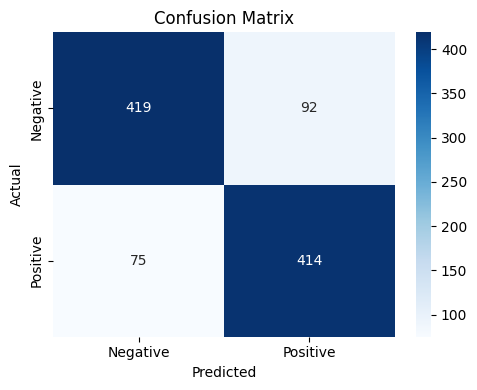

In [9]:
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

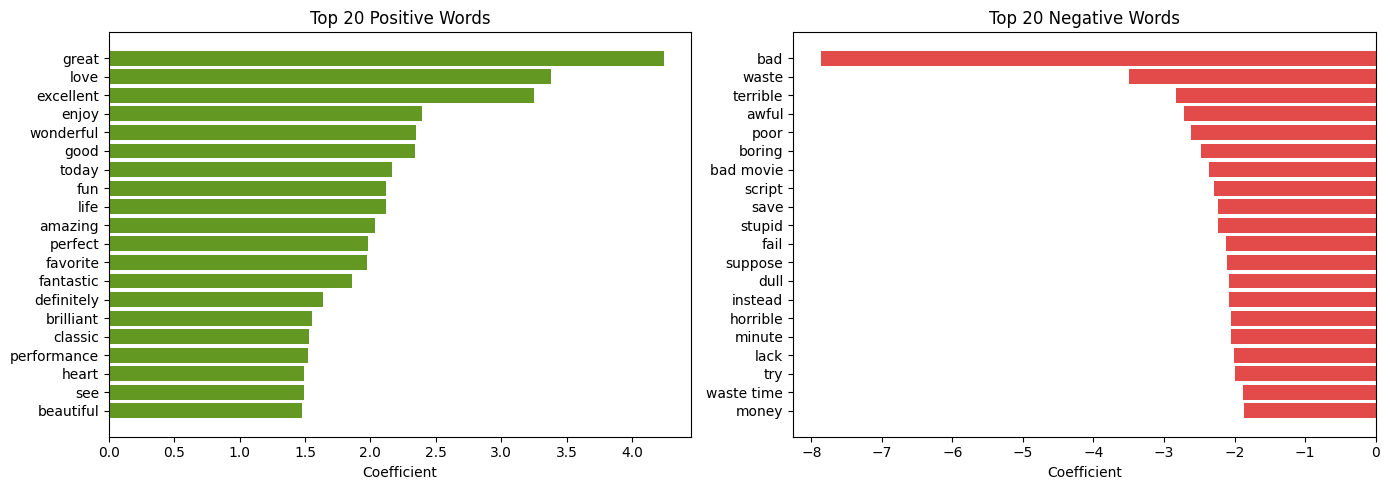

In [10]:
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]

top_pos_idx = coefs.argsort()[-20:][::-1]
top_neg_idx = coefs.argsort()[:20]

top_pos_words = [feature_names[i] for i in top_pos_idx]
top_neg_words = [feature_names[i] for i in top_neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_pos_words[::-1], coefs[top_pos_idx][::-1], color="#639922")
axes[0].set_title("Top 20 Positive Words")
axes[0].set_xlabel("Coefficient")

axes[1].barh(top_neg_words[::-1], coefs[top_neg_idx][::-1], color="#E24B4A")
axes[1].set_title("Top 20 Negative Words")
axes[1].set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

In [11]:
def predict_sentiment(text):
    clean = preprocess(text)
    vec = vectorizer.transform([clean])
    label = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]
    sentiment = "Positive 😊" if label == 1 else "Negative 😞"
    confidence = max(proba) * 100
    print(f"Text:       {text}")
    print(f"Sentiment:  {sentiment}")
    print(f"Confidence: {confidence:.1f}%")
    print("-" * 50)

predict_sentiment("This movie was absolutely amazing, I loved every second!")
predict_sentiment("Terrible film, complete waste of time and money.")
predict_sentiment("It was okay, nothing special but not bad either.")

Text:       This movie was absolutely amazing, I loved every second!
Sentiment:  Positive 😊
Confidence: 82.7%
--------------------------------------------------
Text:       Terrible film, complete waste of time and money.
Sentiment:  Negative 😞
Confidence: 92.6%
--------------------------------------------------
Text:       It was okay, nothing special but not bad either.
Sentiment:  Negative 😞
Confidence: 93.8%
--------------------------------------------------


In [12]:
pickle.dump(model, open("sentiment_model.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))
print("✅ Model saved as 'sentiment_model.pkl'")
print("✅ Vectorizer saved as 'tfidf_vectorizer.pkl'")

✅ Model saved as 'sentiment_model.pkl'
✅ Vectorizer saved as 'tfidf_vectorizer.pkl'


In [13]:
print(f"Final Test Accuracy: {test_acc*100:.2f}%")
print(f"Model: Logistic Regression + TF-IDF")
print(f"Dataset: IMDB (5000 train, 1000 test samples)")

Final Test Accuracy: 83.30%
Model: Logistic Regression + TF-IDF
Dataset: IMDB (5000 train, 1000 test samples)
